<a href="https://colab.research.google.com/github/fur-ruf/data_analysis/blob/main/lab7_mashine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №7
## MLP

Выполнила: Будюкова Полина (408326)

Группа: P3321

Преподаватель: Солодкая Мария Александровна


### Цель работы:
Создать архитектуру многослойного персептрона, классифицирующего грибы (mushroom_dataset).

### Задание:
1. 2 скрытых слоя, функция активации сигмоида, градиентный спуск без оптимизаторов.
2. Выходных нейрона 1 или 2, по количеству классов (выбор количества нейронов на усмотрение обучающегося).
3. Обучить нейронную сеть.
4. Посчитать accuracy, precision, recall, F1-меру.
5. Вывести ROC-кривую.


### Получение данных

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('sample_data/Mushroom_dataset', header=None)

X_raw = df.iloc[:, 1:].values
y_raw = df.iloc[:, 0].values

print(f"Размер данных: {X_raw.shape}")
print(f"Уникальные классы: {np.unique(y_raw)}")

y = np.array([1 if val == 'EDIBLE' else 0 for val in y_raw])
print(f"Распределение классов: EDIBLE={np.sum(y==1)}, POISONOUS={np.sum(y==0)}")

def one_hot_encode(X_categorical):
    n_samples = X_categorical.shape[0]
    n_features = X_categorical.shape[1]
    encoded_features = []

    for col in range(n_features):
        unique_vals = np.unique(X_categorical[:, col])
        one_hot = np.zeros((n_samples, len(unique_vals)))
        for i, val in enumerate(unique_vals):
            one_hot[:, i] = (X_categorical[:, col] == val).astype(int)
        encoded_features.append(one_hot)

    return np.hstack(encoded_features)

X = one_hot_encode(X_raw)
print(f"После one-hot кодирования: {X.shape[1]} признаков")

def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    std[std == 0] = 1
    return (X - mean) / std, mean, std

X, X_mean, X_std = standardize(X)

def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)
    split_idx = int(n_samples * (1 - test_size))
    train_idx = indices[:split_idx]
    test_idx = indices[split_idx:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.2)

print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")

X_train_final, X_val, y_train_final, y_val = train_test_split_manual(X_train, y_train, test_size=0.2, random_state=123)

print(f"Train: {X_train_final.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Размер данных: (8416, 22)
Уникальные классы: ['EDIBLE' 'POISONOUS']
Распределение классов: EDIBLE=4488, POISONOUS=3928
После one-hot кодирования: 117 признаков
Обучающая выборка: 6732 samples
Тестовая выборка: 1684 samples
Train: 5385, Val: 1347, Test: 1684


### Алгоритмы

In [ ]:
class NeuralNetwork:
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size, learning_rate=0.0005):
        self.W1 = np.random.randn(input_size, hidden1_size) * np.sqrt(1.0 / input_size)
        self.b1 = np.zeros((1, hidden1_size))
        self.W2 = np.random.randn(hidden1_size, hidden2_size) * np.sqrt(1.0 / hidden1_size)
        self.b2 = np.zeros((1, hidden2_size))
        self.W3 = np.random.randn(hidden2_size, output_size) * np.sqrt(1.0 / hidden2_size)
        self.b3 = np.zeros((1, output_size))

        self.learning_rate = learning_rate
        self.best_loss = float('inf')
        self.best_params = None

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def sigmoid(self, x):
        x = np.clip(x, -50, 50)
        return 1 / (1 + np.exp(-x))

    def forward(self, X, cache=True):
        z1 = np.dot(X, self.W1) + self.b1
        a1 = self.relu(z1)

        z2 = np.dot(a1, self.W2) + self.b2
        a2 = self.relu(z2)

        z3 = np.dot(a2, self.W3) + self.b3
        output = self.sigmoid(z3)

        output = np.clip(output, 1e-7, 1 - 1e-7)

        if cache:
            self.X, self.a1, self.a2 = X, a1, a2
            self.output = output

        return output

    def compute_loss(self, y_true, y_pred):
        return -np.mean(
            y_true * np.log(y_pred + 1e-8) +
            (1 - y_true) * np.log(1 - y_pred + 1e-8)
        )

    def backward(self, y_true):
        n = self.X.shape[0]
        d_z3 = self.output - y_true.reshape(-1, 1)
        clip_val = 5.0

        d_W3 = np.clip(np.dot(self.a2.T, d_z3) / n, -clip_val, clip_val)
        d_b3 = np.clip(np.sum(d_z3, axis=0, keepdims=True) / n, -clip_val, clip_val)

        d_a2 = np.dot(d_z3, self.W3.T)
        d_z2 = d_a2 * self.relu_derivative(self.a2)
        d_W2 = np.clip(np.dot(self.a1.T, d_z2) / n, -clip_val, clip_val)
        d_b2 = np.clip(np.sum(d_z2, axis=0, keepdims=True) / n, -clip_val, clip_val)

        d_a1 = np.dot(d_z2, self.W2.T)
        d_z1 = d_a1 * self.relu_derivative(self.a1)
        d_W1 = np.clip(np.dot(self.X.T, d_z1) / n, -clip_val, clip_val)
        d_b1 = np.clip(np.sum(d_z1, axis=0, keepdims=True) / n, -clip_val, clip_val)

        self.W3 -= self.learning_rate * d_W3
        self.b3 -= self.learning_rate * d_b3
        self.W2 -= self.learning_rate * d_W2
        self.b2 -= self.learning_rate * d_b2
        self.W1 -= self.learning_rate * d_W1
        self.b1 -= self.learning_rate * d_b1

    def train_step(self, X_batch, y_batch):
        output = self.forward(X_batch, cache=True)
        self.backward(y_batch)
        return self.compute_loss(y_batch, output.flatten())

    def train(self, X_train, y_train, X_val, y_val, epochs=100, batch_size=64, patience=15, verbose=True):
        n = X_train.shape[0]
        train_losses, val_losses = [], []
        patience_counter = 0

        for epoch in range(epochs):
            idx = np.random.permutation(n)
            X_shuffled, y_shuffled = X_train[idx], y_train[idx]

            epoch_losses = []
            for i in range(0, n, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                loss = self.train_step(X_batch, y_batch)
                epoch_losses.append(loss)

            train_loss = np.mean(epoch_losses)
            val_loss = self.evaluate_loss(X_val, y_val)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if val_loss < self.best_loss:
                self.best_loss = val_loss
                self.best_params = (
                    self.W1.copy(), self.b1.copy(),
                    self.W2.copy(), self.b2.copy(),
                    self.W3.copy(), self.b3.copy()
                )
                patience_counter = 0
                if verbose:
                    print(f"Epoch {epoch:3d}: val_loss={val_loss:.6f} (best), train_loss={train_loss:.6f}")
            else:
                patience_counter += 1

            if verbose and epoch % 20 == 0 and epoch > 0:
                print(f"Epoch {epoch:3d}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}, patience={patience_counter}")

            if patience_counter >= patience:
                break

        if self.best_params:
            self.W1, self.b1, self.W2, self.b2, self.W3, self.b3 = self.best_params
            print(f"\nВосстановлена лучшая модель с val_loss={self.best_loss:.6f}")

        return train_losses, val_losses

    def evaluate_loss(self, X, y):
        output = self.forward(X, cache=False).flatten()
        return self.compute_loss(y, output)

    def predict(self, X):
        return (self.forward(X, cache=False).flatten() >= 0.5).astype(int)

    def predict_proba(self, X):
        return self.forward(X, cache=False).flatten()

### Метрики

In [ ]:
def calculate_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': np.array([[tn, fp], [fn, tp]])
    }

### Основная часть


Архитектура сети:
Входной слой: 117 нейронов
Первый скрытый слой: 64 нейронов
Второй скрытый слой: 32 нейронов
Выходной слой: 1 нейрон
Batch size: 64

Начало обучения...
Epoch   0: val_loss=0.661140 (best), train_loss=0.676580
Epoch   1: val_loss=0.641159 (best), train_loss=0.655364
Epoch   2: val_loss=0.621568 (best), train_loss=0.635758
Epoch   3: val_loss=0.602151 (best), train_loss=0.616971
Epoch   4: val_loss=0.582667 (best), train_loss=0.597992
Epoch   5: val_loss=0.562985 (best), train_loss=0.578607
Epoch   6: val_loss=0.543108 (best), train_loss=0.559145
Epoch   7: val_loss=0.522795 (best), train_loss=0.539283
Epoch   8: val_loss=0.502208 (best), train_loss=0.519918
Epoch   9: val_loss=0.481437 (best), train_loss=0.498695
Epoch  10: val_loss=0.460526 (best), train_loss=0.478167
Epoch  11: val_loss=0.439620 (best), train_loss=0.457961
Epoch  12: val_loss=0.418731 (best), train_loss=0.436920
Epoch  13: val_loss=0.398127 (best), train_loss=0.417534
Epoch  14: val_loss=0.377904 (b

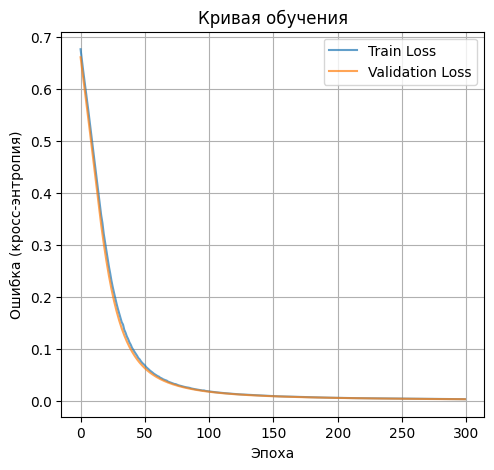

In [ ]:
input_size = X_train.shape[1]
hidden1_size = 64
hidden2_size = 32
output_size = 1

print(f"\nАрхитектура сети:")
print(f"Входной слой: {input_size} нейронов")
print(f"Первый скрытый слой: {hidden1_size} нейронов")
print(f"Второй скрытый слой: {hidden2_size} нейронов")
print(f"Выходной слой: {output_size} нейрон")
print(f"Batch size: 64")

nn = NeuralNetwork(
    input_size=input_size,
    hidden1_size=64,
    hidden2_size=32,
    output_size=1,
    learning_rate=0.001
)

print("\nНачало обучения...")
train_losses, val_losses = nn.train(X_train_final, y_train_final, X_val, y_val,
                                     epochs=300, batch_size=64, patience=50, verbose=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', alpha=0.7)
plt.plot(val_losses, label='Validation Loss', alpha=0.7)
plt.xlabel('Эпоха')
plt.ylabel('Ошибка (кросс-энтропия)')
plt.title('Кривая обучения')
plt.legend()
plt.grid(True)


y_pred = nn.predict(X_test)
y_pred_proba = nn.predict_proba(X_test)

metrics = calculate_metrics(y_test, y_pred)

print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print(f"Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"F1-score:  {metrics['f1']:.4f}")
print(f"\nМатрица ошибок:")
print(f"            Предсказано")
print(f"           0      1")
print(f"Факт 0:  {metrics['confusion_matrix'][0,0]:3d}    {metrics['confusion_matrix'][0,1]:3d}")
print(f"Факт 1:  {metrics['confusion_matrix'][1,0]:3d}    {metrics['confusion_matrix'][1,1]:3d}")

### ROC-кривая

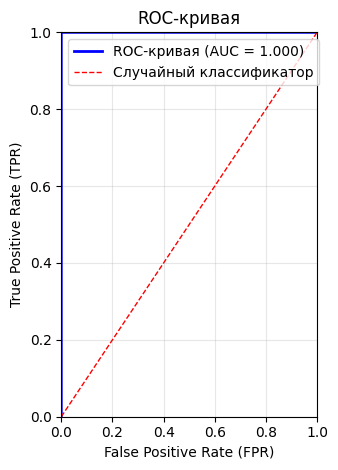

In [ ]:
def calculate_roc(y_true, y_scores):
    indices = np.argsort(y_scores)[::-1]
    y_true_sorted = y_true[indices]

    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)

    tpr = [0]
    fpr = [0]

    tp = 0
    fp = 0

    for i in range(len(y_true_sorted)):
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1

        tpr.append(tp / n_pos if n_pos > 0 else 0)
        fpr.append(fp / n_neg if n_neg > 0 else 0)

    auc_score = np.trapezoid(tpr, fpr)

    return fpr, tpr, auc_score

fpr, tpr, auc_score = calculate_roc(y_test, y_pred_proba)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC-кривая (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Случайный классификатор')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

### Итог

In [ ]:
print("ИТОГОВЫЙ АНАЛИЗ")
print(f"Точность: {metrics['accuracy']*100:.2f}%")
print(f"Сеть правильно классифицировала {np.sum(y_pred == y_test)} из {len(y_test)} грибов")
print(f"Ошибок: {np.sum(y_pred != y_test)}")
print(f"AUC: {auc_score:.3f}")

print(f"Лучшая ошибка на валидации: {nn.best_loss:.6f}")
print(f"Финальная ошибка на валидации: {val_losses[-1]:.6f}")

ИТОГОВЫЙ АНАЛИЗ
Точность: 100.00%
Сеть правильно классифицировала 1684 из 1684 грибов
Ошибок: 0
AUC: 1.000
Лучшая ошибка на валидации: 0.002998
Финальная ошибка на валидации: 0.002998
